In [2]:
import scanpy as sc
import sys
import pandas as pd
import numpy as np
#sys.path.append('/data_nfs/og86asub/netmap/scGeneRAI')
#from scGeneRAI import scGeneRAI
#import os
#import networkx as nx

In [3]:
ex_data= pd.read_csv('/data_nfs/og86asub/netmap/netmap-evaluation/src/manuscript_synthetic/manuscript_results/figures/epi_top2000.csv')
ex_data_descriptors = ex_data.iloc[:, 2002:2012].copy()

In [5]:
ada2 = sc.read_h5ad('/data/bionets/og86asub/netmap/netmap-evaluation/src/manuscript_synthetic/manuscript_results/scgenerai.h5ad')
sc.pp.scale(ada2)
sc.pp.normalize_total(ada2)
sc.tl.pca(ada2)
sc.pp.neighbors(ada2)
sc.tl.umap(ada2)


/tmp/ipykernel_4024093/1944422589.py:3: UserWarning: Some cells have zero counts
  sc.pp.normalize_total(ada2)
/data/bionets/og86asub/krebshilfe/data_integation/.pixi/envs/default/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


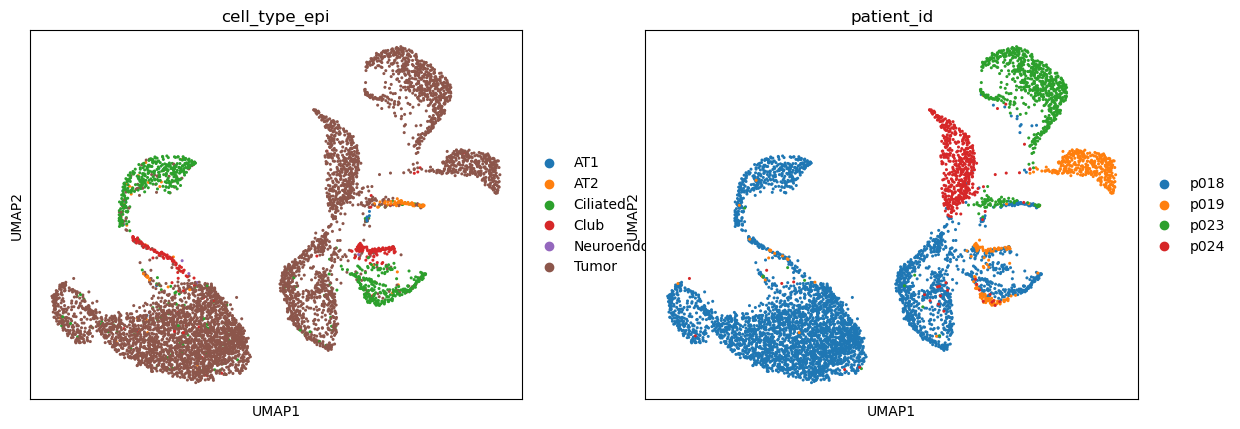

In [6]:
sc.pl.umap(ada2,  color =['cell_type_epi', 'patient_id'])

In [ ]:
network_data = pd.concat([pd.read_csv('./results/' + file) for file in files])

In [62]:
aa

array([[0.0208031 , 0.01047545, 0.08224458, ..., 0.00872666, 0.07444498,
        0.14176513],
       [0.00916782, 0.01674173, 0.042429  , ..., 0.00297794, 0.01207292,
        0.16203107],
       [0.02808644, 0.02661763, 0.03118689, ..., 0.00798006, 0.04089255,
        0.19420235],
       ...,
       [0.00355798, 0.01468781, 0.06679331, ..., 0.00535908, 0.00658589,
        0.05821839],
       [0.03029862, 0.03427286, 0.07681311, ..., 0.00796951, 0.00497993,
        0.18447077],
       [0.01518424, 0.01209599, 0.10090432, ..., 0.01076193, 0.03544436,
        0.06342612]], shape=(50, 66))

In [50]:
network_data['LRP'] = np.abs(network_data['LRP'])
network_data = network_data[network_data['source_gene'] != network_data['target_gene']]

average_network = network_data[['LRP', 'source_gene', 'target_gene']].groupby(['source_gene', 'target_gene']).mean().reset_index()

In [51]:
edges = average_network.sort_values(by='LRP', ascending=False).iloc[:20,:]
edges


,source_gene,target_gene,LRP
65,RPS27,RPL10,0.136783
45,RPL10,EEF1A1,0.104485
37,JUN,FOS,0.093927
2,FOSB,FOS,0.088003
38,JUN,FOSB,0.080692
55,RPS27,EEF1A1,0.067608
50,RPL10,ID1,0.031201
47,RPL10,FOSB,0.029794
42,JUN,ID2,0.029305
9,HSPA5,HSP90B1,0.028945


In [52]:
network_data

,Unnamed: 0,LRP,source_gene,target_gene
0,1,0.025832,ID2,ID1
1,2,0.026503,ID3,ID1
2,3,0.032464,ID4,ID1
3,4,0.080794,JUN,ID1
4,9,0.008886,RPS27,ID1
...,...,...,...,...
61,138,0.026531,FOSB,EEF1A1
62,139,0.002689,HSPA5,EEF1A1
63,140,0.020675,HSP90B1,EEF1A1
64,141,0.044947,RPS27,EEF1A1


In [25]:
ex_data_us = pd.read_csv('/data_nfs/og86asub/netmap/netmap-evaluation/src/methods/scgenerai/example_data.csv').iloc[:,3:]


In [ ]:
ada = sc.AnnData(X = ex_data_us, obs = ex_data_descriptors)
sc.pp.scale(ada)
sc.pp.normalize_total(ada)
sc.tl.pca(ada)
sc.pp.neighbors(ada)
sc.tl.umap(ada)
sc.pl.umap(ada, save=True)

/data_nfs/og86asub/netmap/netmap-evaluation/netmap/.pixi/envs/default/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/tmp/ipykernel_2375460/2052148772.py:3: UserWarning: Some cells have zero counts
  sc.pp.normalize_total(ada)


KeyboardInterrupt: 

/data_nfs/og86asub/netmap/netmap-evaluation/netmap/.pixi/envs/default/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/tmp/ipykernel_2375460/3098902336.py:3: UserWarning: Some cells have zero counts
  sc.pp.normalize_total(ada2)
/tmp/ipykernel_2375460/3098902336.py:7: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(ada2, save=True)


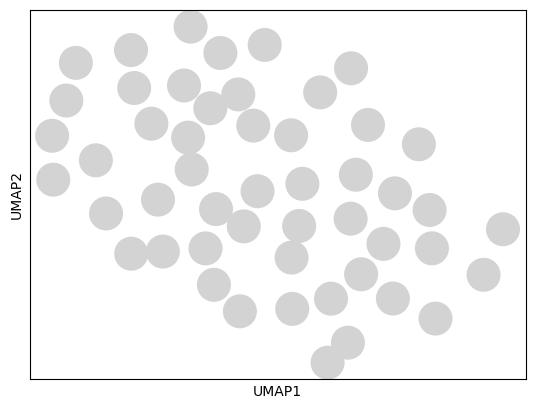

/tmp/ipykernel_2375460/2759336595.py:1: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(ada, save=True)


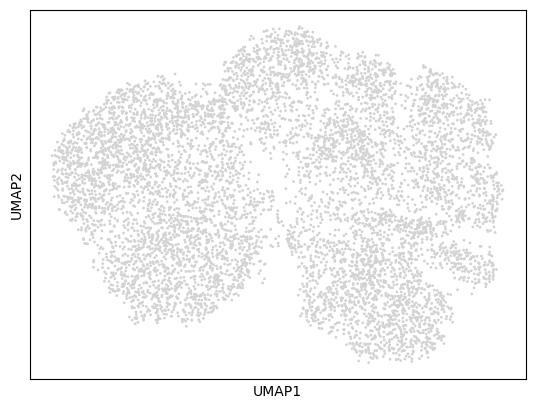

In [57]:
network_data

,Unnamed: 0,LRP,source_gene,target_gene
0,1,0.025832,ID2,ID1
1,2,0.026503,ID3,ID1
2,3,0.032464,ID4,ID1
3,4,0.080794,JUN,ID1
4,9,0.008886,RPS27,ID1
...,...,...,...,...
61,138,0.026531,FOSB,EEF1A1
62,139,0.002689,HSPA5,EEF1A1
63,140,0.020675,HSP90B1,EEF1A1
64,141,0.044947,RPS27,EEF1A1


In [56]:
res_data = network_data.drop(network_data.columns[0], axis=1)
#mean_resda = res_data[['LRP', 'source_gene', 'target_gene']].groupby(['source_gene', 'target_gene']).mean().reset_index()
#get aa and nl like netmap
unique_edges = res_data[['source_gene', 'target_gene']].drop_duplicates()

nl = [(row['source_gene'], row['target_gene']) for _, row in unique_edges.iterrows()]

pivot_table = res_data.pivot_table(index='cell_name', columns=['source_gene', 'target_gene'], values='LRP', fill_value=0)
aa = pivot_table.values


KeyError: 'cell_name'